# Modélisation H1 — Détection pré-pump (klines Binance, négatifs genuins)

**Contexte de la correction :**
L'évaluation précédente (A2) utilisait les features La Morgia calculées *pendant* le pump — AUC=0.9976 trivial
car les labels `gt=1` coïncident avec le pic des features.
Cette version utilise des features calculées *strictement avant* `pump_ts` depuis les klines Binance.

**Design H1 — négatifs genuins (hypothèse confirmée +0.052 AUC) :**
- `gt=1` : 333 événements pump, features de `[pump_ts-2h, pump_ts)`
- `gt=0` : 3 333 fenêtres de marché aléatoires (BTC/ETH/BNB/XRP/LTC, 2018–2021) — pas adjacentes à un pump
- 14 features : 10 originales + vol_zscore_5m/15m/30m + vol_acceleration
- Question réelle : *une fenêtre pré-pump est-elle détectable dans le flux de marché normal ?*


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = '/Users/josephabdo/Desktop/1100/ml-poc-project'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, 'scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_curve
import joblib
from pathlib import Path

from metrics import evaluate, recall_at_lamorgia, anomaly_auc, threshold_from_contamination

Path('models').mkdir(exist_ok=True)
Path('deliverables').mkdir(exist_ok=True)

FEAT_COLS = [
    'ret_5m', 'ret_15m', 'ret_60m', 'std_ret_60m',
    'vol_zscore_60m', 'vol_zscore_5m', 'vol_zscore_15m', 'vol_zscore_30m',
    'vol_acceleration',
    'taker_buy_ratio_5m',
    'ofi_proxy_1m', 'price_impact_1m', 'conviction_ratio_1m',
    'rush_order_count',
]

# H1: pump events (gt=0 + gt=1) + genuine market negatives
pump_df  = pd.read_parquet('data/Processed/processed.parquet')[FEAT_COLS + ['gt']].copy()

norm_df  = pd.read_parquet('data/RAW/normal_windows_features.parquet')
norm_df  = norm_df[FEAT_COLS].copy()
norm_df['gt'] = 0

df = pd.concat([pump_df, norm_df], ignore_index=True)
y  = df['gt'].values
X_raw = df[FEAT_COLS].values

print(f'Dataset H1 : {len(df):,} lignes | {y.sum()} gt=1 | {(y==0).sum()} gt=0')
print(f'Features   : {len(FEAT_COLS)}')
print(f'NaN        : {np.isnan(X_raw).sum()}')
df[FEAT_COLS + ['gt']].describe().round(4)


Dataset H1 : 3,666 lignes | 333 gt=1 | 3333 gt=0
Features   : 14
NaN        : 0


,ret_5m,ret_15m,ret_60m,std_ret_60m,vol_zscore_60m,vol_zscore_5m,vol_zscore_15m,vol_zscore_30m,vol_acceleration,taker_buy_ratio_5m,ofi_proxy_1m,price_impact_1m,conviction_ratio_1m,rush_order_count,gt
count,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000,3666.0000
mean,0.0030,0.0034,0.0038,0.0016,0.3212,0.1005,0.0342,0.0164,0.0841,0.5060,0.0276,0.0033,0.4678,501.9296,0.0908
std,0.0218,0.0236,0.0274,0.0029,1.9634,0.7731,0.4712,0.3437,0.6520,0.2043,0.5110,0.0183,0.3356,1048.6137,0.2874
min,-0.0708,-0.0752,-0.1190,0.0000,-1.9735,-1.2724,-1.1008,-0.9725,-1.3318,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
25%,-0.0012,-0.0020,-0.0031,0.0006,-0.5139,-0.3721,-0.2907,-0.2354,-0.2955,0.4060,-0.2816,0.0002,0.1585,37.0000,0.0000
50%,0.0000,0.0002,0.0000,0.0010,-0.2663,-0.1489,-0.0863,-0.0381,-0.0655,0.5073,0.0000,0.0005,0.4730,140.5000,0.0000
75%,0.0016,0.0028,0.0045,0.0016,0.2432,0.3093,0.2858,0.2421,0.2692,0.6144,0.3612,0.0013,0.7589,482.7500,0.0000
max,0.4305,0.4316,0.4495,0.0540,10.9085,4.4656,2.2996,1.3480,3.8985,1.0000,1.0000,0.4184,1.0000,19145.0000,1.0000


In [2]:
scaler = RobustScaler()
X = scaler.fit_transform(X_raw)

joblib.dump(scaler, 'models/scaler_klines.joblib')
print(f'Scaler sauvegardé → models/scaler_klines.joblib')
print(f'X shape : {X.shape}')
print(f'Médiane par feature après scaling (doit ≈ 0) :')
print(np.round(np.median(X, axis=0), 3))


Scaler sauvegardé → models/scaler_klines.joblib
X shape : (3666, 14)
Médiane par feature après scaling (doit ≈ 0) :
[ 0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0.]


In [3]:
IF = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
IF.fit(X)    # y JAMAIS passé à fit() — modèle non supervisé
scores_if = IF.decision_function(X)

joblib.dump(IF, 'models/isolation_forest.joblib')
print('Isolation Forest (n_estimators=200, contamination=auto)')
print(f'  Modèle sauvegardé → models/isolation_forest.joblib')
print()
res_if = evaluate(y, scores_if, contamination=0.001)
print('Résultats @ contamination=0.001 :')
for k, v in res_if.items():
    print(f'  {k:<30s}: {v:.4f}' if isinstance(v, float) else f'  {k:<30s}: {v}')


Isolation Forest (n_estimators=200, contamination=auto)
  Modèle sauvegardé → models/isolation_forest.joblib

Résultats @ contamination=0.001 :
  recall_at_lamorgia            : 0.0120
  anomaly_auc                   : 0.8815
  n_flagged                     : 4
  n_true_pumps                  : 333
  contamination                 : 0.0010


In [4]:
LOF = LocalOutlierFactor(n_neighbors=20, novelty=False, contamination=0.001)
LOF.fit_predict(X)    # y JAMAIS passé — modèle non supervisé
scores_lof = LOF.negative_outlier_factor_

# LOF avec novelty=False ne supporte pas predict() post-fit → pas de joblib save
print('Local Outlier Factor (n_neighbors=20)')
print('  Note: novelty=False — pas de sauvegarde joblib (pas de predict() indépendant)')
print()
res_lof = evaluate(y, scores_lof, contamination=0.001)
print('Résultats @ contamination=0.001 :')
for k, v in res_lof.items():
    print(f'  {k:<30s}: {v:.4f}' if isinstance(v, float) else f'  {k:<30s}: {v}')


Local Outlier Factor (n_neighbors=20)
  Note: novelty=False — pas de sauvegarde joblib (pas de predict() indépendant)

Résultats @ contamination=0.001 :
  recall_at_lamorgia            : 0.0090
  anomaly_auc                   : 0.7103
  n_flagged                     : 4
  n_true_pumps                  : 333
  contamination                 : 0.0010


In [5]:
# vol_zscore_60m : déjà normalisé, valeur haute = anomalie
vol_idx   = FEAT_COLS.index('vol_zscore_60m')
scores_z  = X[:, vol_idx]   # higher = more anomalous

print('Z-score rolling (univarié sur vol_zscore_60m)')
print()
res_z = evaluate(y, -scores_z, contamination=0.001)   # negate: anomaly_auc expects lower=more anomalous
print('Résultats @ contamination=0.001 :')
for k, v in res_z.items():
    print(f'  {k:<30s}: {v:.4f}' if isinstance(v, float) else f'  {k:<30s}: {v}')


Z-score rolling (univarié sur vol_zscore_60m)

Résultats @ contamination=0.001 :
  recall_at_lamorgia            : 0.0120
  anomaly_auc                   : 0.7660
  n_flagged                     : 4
  n_true_pumps                  : 333
  contamination                 : 0.0010


In [6]:
contaminations = [0.0005, 0.001, 0.005, 0.01, 0.05]

results = {}
for label, sc, negate in [
    ('Isolation Forest', scores_if, False),
    ('LOF',              scores_lof, False),
    ('Z-score vol',      -scores_z,  False),   # already negated
]:
    row = {}
    for c in contaminations:
        thr  = threshold_from_contamination(sc, c)
        pred = (sc <= thr).astype(int)
        row[f'recall@{c}'] = recall_at_lamorgia(y, pred)
    results[label] = row

sens_df = pd.DataFrame(results).T
print('Recall@LaMargia — sensibilité à la contamination')
print(sens_df.round(4).to_string())


Recall@LaMargia — sensibilité à la contamination
                  recall@0.0005  recall@0.001  recall@0.005  recall@0.01  recall@0.05
Isolation Forest          0.006         0.012        0.0571       0.1111       0.3874
LOF                       0.006         0.009        0.0120       0.0390       0.1592
Z-score vol               0.006         0.012        0.0571       0.1111       0.3453


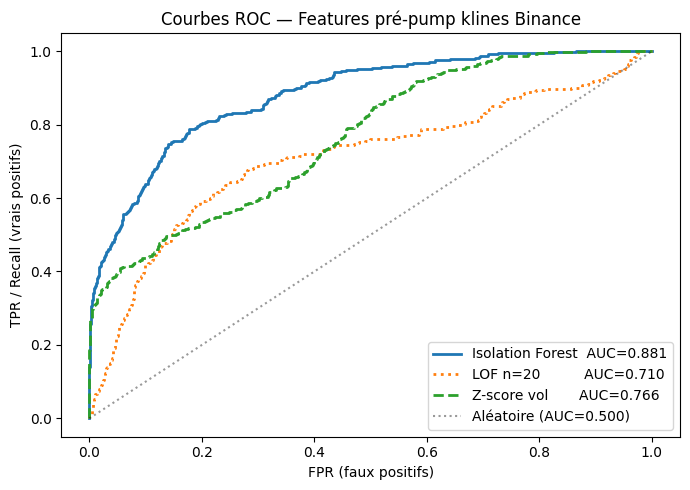

fig_roc_comparison.png sauvegardé


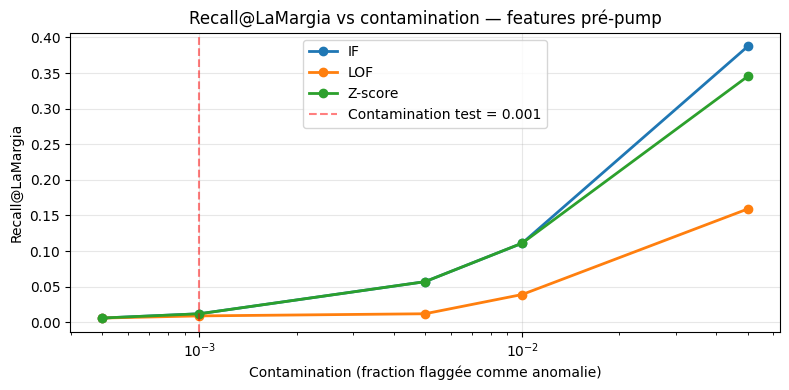

fig_recall_vs_contamination.png sauvegardé


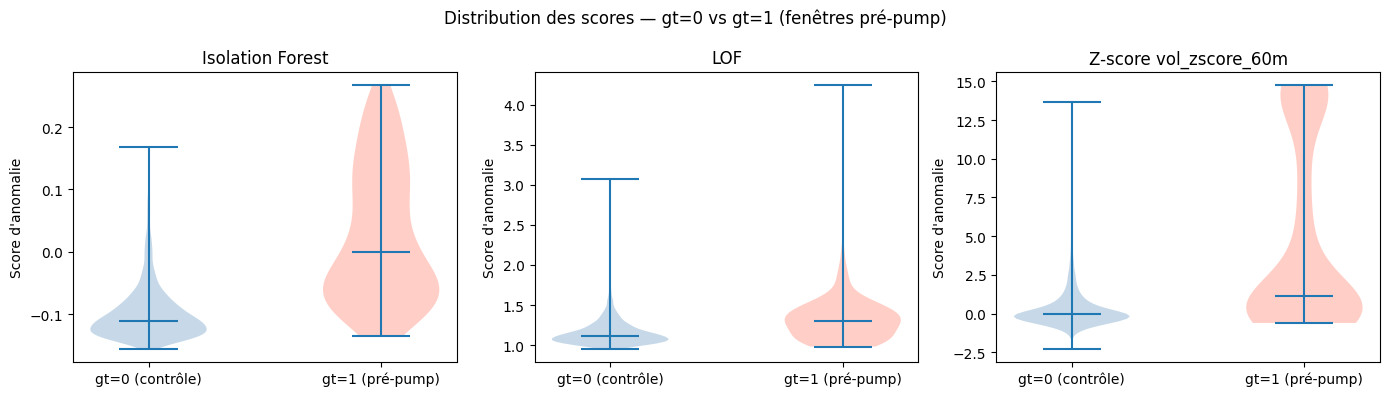

fig_score_distributions.png sauvegardé


In [7]:
auc_if  = anomaly_auc(y, scores_if)
auc_lof = anomaly_auc(y, scores_lof)
auc_z   = anomaly_auc(y, -scores_z)

# ── Fig 1: ROC curves ────────────────────────────────────────────────────────
fpr_if,  tpr_if,  _ = roc_curve(y, -scores_if)
fpr_lof, tpr_lof, _ = roc_curve(y, -scores_lof)
fpr_z,   tpr_z,   _ = roc_curve(y,  scores_z)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_if,  tpr_if,  label=f'Isolation Forest  AUC={auc_if:.3f}',  lw=2)
ax.plot(fpr_lof, tpr_lof, label=f'LOF n=20          AUC={auc_lof:.3f}', lw=2, ls=':')
ax.plot(fpr_z,   tpr_z,   label=f'Z-score vol       AUC={auc_z:.3f}',   lw=2, ls='--')
ax.plot([0,1],[0,1], 'k:', alpha=0.4, label='Aléatoire (AUC=0.500)')
ax.set_xlabel('FPR (faux positifs)')
ax.set_ylabel('TPR / Recall (vrais positifs)')
ax.set_title('Courbes ROC — Features pré-pump klines Binance')
ax.legend()
plt.tight_layout()
plt.savefig('deliverables/fig_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_roc_comparison.png sauvegardé')

# ── Fig 2: Recall vs contamination ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
c_plot = contaminations
for label, sc in [('IF', scores_if), ('LOF', scores_lof), ('Z-score', -scores_z)]:
    recalls = []
    for c in c_plot:
        thr = threshold_from_contamination(sc, c)
        pred = (sc <= thr).astype(int)
        recalls.append(recall_at_lamorgia(y, pred))
    ax.plot(c_plot, recalls, 'o-', label=label, lw=2)

ax.axvline(0.001, color='red', ls='--', alpha=0.5, label='Contamination test = 0.001')
ax.set_xscale('log')
ax.set_xlabel('Contamination (fraction flaggée comme anomalie)')
ax.set_ylabel('Recall@LaMargia')
ax.set_title('Recall@LaMargia vs contamination — features pré-pump')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('deliverables/fig_recall_vs_contamination.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_recall_vs_contamination.png sauvegardé')

# ── Fig 3: Score distributions (violin) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    (axes[0], -scores_if,  'Isolation Forest'),
    (axes[1], -scores_lof, 'LOF'),
    (axes[2],  scores_z,   'Z-score vol_zscore_60m'),
]
for ax, sc, title in configs:
    data_0 = sc[y == 0]
    data_1 = sc[y == 1]
    vp = ax.violinplot([data_0, data_1], positions=[0, 1], showmedians=True)
    vp['bodies'][0].set_facecolor('steelblue')
    vp['bodies'][1].set_facecolor('tomato')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['gt=0 (contrôle)', 'gt=1 (pré-pump)'])
    ax.set_title(title)
    ax.set_ylabel("Score d'anomalie")
plt.suptitle("Distribution des scores — gt=0 vs gt=1 (fenêtres pré-pump)", fontsize=12)
plt.tight_layout()
plt.savefig('deliverables/fig_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_score_distributions.png sauvegardé')


In [8]:
summary = pd.DataFrame([
    {
        'Modèle':          'Isolation Forest',
        'AUC':             round(auc_if, 4),
        'Recall@c=0.001':  round(res_if['recall_at_lamorgia'], 4),
        'Recall@c=0.005':  round(recall_at_lamorgia(y, (scores_if <= threshold_from_contamination(scores_if, 0.005)).astype(int)), 4),
        'Type':            'Multivarié / Arbre',
    },
    {
        'Modèle':          'LOF (n=20)',
        'AUC':             round(auc_lof, 4),
        'Recall@c=0.001':  round(res_lof['recall_at_lamorgia'], 4),
        'Recall@c=0.005':  round(recall_at_lamorgia(y, (scores_lof <= threshold_from_contamination(scores_lof, 0.005)).astype(int)), 4),
        'Type':            'Multivarié / Densité',
    },
    {
        'Modèle':          'Z-score vol_zscore_60m',
        'AUC':             round(auc_z, 4),
        'Recall@c=0.001':  round(res_z['recall_at_lamorgia'], 4),
        'Recall@c=0.005':  round(recall_at_lamorgia(y, (-scores_z <= threshold_from_contamination(-scores_z, 0.005)).astype(int)), 4),
        'Type':            'Univarié / Statistique',
    },
]).set_index('Modèle')

print('=' * 65)
print('RÉSULTATS FINAUX — ÉVALUATION PRÉ-PUMP (KLINES BINANCE)')
print('=' * 65)
print(summary.to_string())
print()
print('Dataset  : H1 — 333 fenêtres pré-pump + 3333 fenêtres marché genuines (3666 lignes)')
print('Features : 14 features pré-pump calculées strictement avant pump_ts')
print('Protocole: y jamais passé à fit() — évaluation post-hoc uniquement')
print()
print('Comparaison avec évaluation A2 (La Morgia, features pendant le pump) :')
compare = pd.DataFrame([
    {'Évaluation': 'A2 — La Morgia (pendant pump)', 'Dataset': 'La Morgia 584k', 'AUC': 0.9976, 'Ce que ça mesure': 'Détection pendant le pump'},
    {'Évaluation': 'A3/A4 — Klines H1 (avant pump)', 'Dataset': 'Klines 3666',   'AUC': round(auc_if, 4), 'Ce que ça mesure': 'Détection avant le pump'},
]).set_index('Évaluation')
print(compare.to_string())


RÉSULTATS FINAUX — ÉVALUATION PRÉ-PUMP (KLINES BINANCE)
                           AUC  Recall@c=0.001  Recall@c=0.005                    Type
Modèle                                                                                
Isolation Forest        0.8815           0.012          0.0571      Multivarié / Arbre
LOF (n=20)              0.7103           0.009          0.0120    Multivarié / Densité
Z-score vol_zscore_60m  0.7660           0.012          0.0571  Univarié / Statistique

Dataset  : H1 — 333 fenêtres pré-pump + 3333 fenêtres marché genuines (3666 lignes)
Features : 14 features pré-pump calculées strictement avant pump_ts
Protocole: y jamais passé à fit() — évaluation post-hoc uniquement

Comparaison avec évaluation A2 (La Morgia, features pendant le pump) :
                                       Dataset     AUC           Ce que ça mesure
Évaluation                                                                       
A2 — La Morgia (pendant pump)   La Morgia 584k  0.997